In [10]:
!pip install xlrd

In [25]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Extract and download data to folder

In [28]:
urls = [
    'http://tennis-data.co.uk/2000/2000.xls', 
    #'http://tennis-data.co.uk/2001/2001.xls', 
    'http://tennis-data.co.uk/2002/2002.xls',
    'http://tennis-data.co.uk/2003/2003.xls', 
    'http://tennis-data.co.uk/2004/2004.xls',
    'http://tennis-data.co.uk/2005/2005.xls', 
    'http://tennis-data.co.uk/2006/2006.xls',
    'http://tennis-data.co.uk/2007/2007.xls', 
    #'http://tennis-data.co.uk/2008/2008.zip', 
    'http://tennis-data.co.uk/2009/2009.xls', 
    'http://tennis-data.co.uk/2010/2010.xls',
    'http://tennis-data.co.uk/2011/2011.xls', 
    'http://tennis-data.co.uk/2012/2012.xls',
    'http://tennis-data.co.uk/2013/2013.xlsx', 
    'http://tennis-data.co.uk/2014/2014.xlsx',
    'http://tennis-data.co.uk/2015/2015.xlsx', 
    'http://tennis-data.co.uk/2016/2016.xlsx', 
    'http://tennis-data.co.uk/2017/2017.xlsx', 
    'http://tennis-data.co.uk/2018/2018.xlsx',
    'http://tennis-data.co.uk/2019/2019.xlsx', 
    'http://tennis-data.co.uk/2020/2020.xlsx',
    'http://tennis-data.co.uk/2021/2021.xlsx', 
    'http://tennis-data.co.uk/2022/2022.xlsx',
    'http://tennis-data.co.uk/2023/2023.xlsx',
    'http://tennis-data.co.uk/2024/2024.xlsx',
    'http://tennis-data.co.uk/2025/2025.xlsx',
    'http://tennis-data.co.uk/2026/2026.xlsx'
]

# Folder to save files
save_folder = "datasets"
os.makedirs(save_folder, exist_ok=True)

for url in urls:
    filename = url.split("/")[-1]
    filepath = os.path.join(save_folder, filename)
    
    print(f"Downloading {filename}...")
    
    response = requests.get(url)
    with open(filepath, "wb") as f:
        f.write(response.content)

## Read data and insert to dataframe

In [4]:
folder_path = "datasets"

# Dictionary to save dataframes
dfs = {}

for file in os.listdir(folder_path):
    filepath = os.path.join(folder_path, file)
    if file.endswith(".xlsx"):
        df = pd.read_excel(filepath)
        
    elif file.endswith(".xls"):
        df = pd.read_excel(filepath, engine="xlrd")
        
    else:
        continue
    
    # Use filename as key
    key = os.path.splitext(file)[0]
    dfs[key] = df
    
    print(f"Loaded {file} → key: '{key}', shape: {df.shape}")

print("\nTotal datasets loaded:", len(dfs))

Loaded 2000.xls → key: '2000', shape: (2963, 26)
Loaded 2001.xls → key: '2001', shape: (2963, 34)
Loaded 2002.xls → key: '2002', shape: (2854, 36)
Loaded 2003.xls → key: '2003', shape: (2861, 36)
Loaded 2004.xls → key: '2004', shape: (2877, 36)
Loaded 2005.xls → key: '2005', shape: (2909, 38)
Loaded 2006.xls → key: '2006', shape: (2909, 38)
Loaded 2007.xls → key: '2007', shape: (2806, 38)
Loaded 2008.xls → key: '2008', shape: (2707, 38)
Loaded 2009.xls → key: '2009', shape: (2731, 38)
Loaded 2010.xls → key: '2010', shape: (2679, 42)
Loaded 2011.xls → key: '2011', shape: (2675, 42)
Loaded 2012.xls → key: '2012', shape: (2607, 42)


C:\Users\brand\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Loaded 2013.xlsx → key: '2013', shape: (2631, 42)


C:\Users\brand\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Loaded 2014.xlsx → key: '2014', shape: (2600, 42)


C:\Users\brand\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Loaded 2015.xlsx → key: '2015', shape: (2630, 40)


C:\Users\brand\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Loaded 2016.xlsx → key: '2016', shape: (2626, 40)
Loaded 2017.xlsx → key: '2017', shape: (2633, 40)
Loaded 2018.xlsx → key: '2018', shape: (2637, 40)
Loaded 2019.xlsx → key: '2019', shape: (2610, 36)
Loaded 2020.xlsx → key: '2020', shape: (1267, 36)
Loaded 2021.xlsx → key: '2021', shape: (2489, 36)
Loaded 2022.xlsx → key: '2022', shape: (2632, 36)
Loaded 2023.xlsx → key: '2023', shape: (2703, 36)
Loaded 2024.xlsx → key: '2024', shape: (2703, 36)
Loaded 2025.xlsx → key: '2025', shape: (2644, 38)
Loaded 2026.xlsx → key: '2026', shape: (444, 38)

Total datasets loaded: 27


## Data cleaning

In [32]:
for year, df in dfs.items():
    unique_cols = set(df.columns) - common_columns
    if unique_cols:
        print(f"Columns only in {year}: {unique_cols}")

Columns only in 2001: {'IWW', 'IWL', 'CBW', 'SBW', 'GBW', 'GBL', 'CBL', 'SBL'}
Columns only in 2002: {'IWW', 'IWL', 'CBW', 'B365L', 'SBW', 'GBW', 'GBL', 'CBL', 'B365W', 'SBL'}
Columns only in 2003: {'IWW', 'B&WL', 'IWL', 'CBW', 'B&WW', 'B365L', 'SBW', 'CBL', 'B365W', 'SBL'}
Columns only in 2004: {'PSL', 'IWW', 'IWL', 'EXL', 'CBW', 'EXW', 'B365L', 'CBL', 'PSW', 'B365W'}
Columns only in 2005: {'PSL', 'B365W', 'WPts', 'IWL', 'IWW', 'EXL', 'CBW', 'EXW', 'B365L', 'LPts', 'CBL', 'PSW'}
Columns only in 2006: {'PSL', 'WPts', 'UBW', 'EXL', 'CBW', 'EXW', 'B365L', 'LPts', 'CBL', 'PSW', 'B365W', 'UBL'}
Columns only in 2007: {'PSL', 'WPts', 'UBW', 'EXL', 'CBW', 'EXW', 'B365L', 'LPts', 'CBL', 'PSW', 'B365W', 'UBL'}
Columns only in 2008: {'PSL', 'WPts', 'UBW', 'EXL', 'EXW', 'B365L', 'LBL', 'LPts', 'PSW', 'UBL', 'B365W', 'LBW'}
Columns only in 2009: {'WPts', 'UBW', 'EXL', 'EXW', 'B365L', 'LBL', 'LPts', 'SJL', 'UBL', 'B365W', 'SJW', 'LBW'}
Columns only in 2010: {'PSL', 'B365W', 'MaxW', 'WPts', 'EXL', '

In [31]:
# Get sets of column names for each year/df
column_sets = [set(df.columns) for df in dfs.values()]

# Find columns present in all dfs
common_columns = set.intersection(*column_sets)

print(f"Columns present in all datasets ({len(common_columns)}):")
print(common_columns)

Columns present in all datasets (26):
{'L5', 'Location', 'Winner', 'Date', 'ATP', 'Comment', 'W2', 'W5', 'L1', 'L3', 'Lsets', 'W4', 'Loser', 'Wsets', 'W1', 'LRank', 'WRank', 'Round', 'Surface', 'Best of', 'L2', 'W3', 'Tournament', 'Series', 'L4', 'Court'}


### Drop 2000-2004 dataframes

In [11]:
years_to_drop = ['2000','2001', '2002', '2003', '2004']

for year in years_to_drop:
    if year in dfs:
        del dfs[year]
    else:
        print(f"{year} not found in dfs")

### Drop bookmaker columns and keep used columns

In [12]:
# Only use data from 2005-2026

# List of columns to keep
columns_to_keep = ['WPts', 'LPts', 'L5', 'Location', 'Winner', 'Date', 'ATP', 'Comment', 'W2', 'W5', 'L1', 'L3', 'Lsets', 'W4', 'Loser', 'Wsets', 'W1', 'LRank', 'WRank', 'Round', 'Surface', 'Best of', 'L2', 'W3', 'Tournament', 'Series', 'L4', 'Court']  

# Drop bookmaker columns across all DataFrames
for key, df in dfs.items():
    # Keep only the columns that exist in both the DataFrame and kept-columns list
    keep_cols = [col for col in df.columns if col in columns_to_keep]
    dfs[key] = df[keep_cols].copy()  # assign back a clean copy
    print(f"{key}: kept columns {dfs[key].columns.tolist()}")

2005: kept columns ['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment']
2006: kept columns ['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment']
2007: kept columns ['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment']
2008: kept columns ['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets',

### Initial inspection

In [13]:
total_rows = 0
for year, df in dfs.items():
    print(f"\n--- {year} ---")
    # number of rows
    n_rows = int(df.shape[0])
    total_rows += n_rows
    # number of columns
    n_cols = df.shape[1]
    print(f"Rows: {n_rows}, Columns: {n_cols}")
print("Total rows:",total_rows)


--- 2005 ---
Rows: 2909, Columns: 28

--- 2006 ---
Rows: 2909, Columns: 28

--- 2007 ---
Rows: 2806, Columns: 28

--- 2008 ---
Rows: 2707, Columns: 28

--- 2009 ---
Rows: 2731, Columns: 28

--- 2010 ---
Rows: 2679, Columns: 28

--- 2011 ---
Rows: 2675, Columns: 28

--- 2012 ---
Rows: 2607, Columns: 28

--- 2013 ---
Rows: 2631, Columns: 28

--- 2014 ---
Rows: 2600, Columns: 28

--- 2015 ---
Rows: 2630, Columns: 28

--- 2016 ---
Rows: 2626, Columns: 28

--- 2017 ---
Rows: 2633, Columns: 28

--- 2018 ---
Rows: 2637, Columns: 28

--- 2019 ---
Rows: 2610, Columns: 28

--- 2020 ---
Rows: 1267, Columns: 28

--- 2021 ---
Rows: 2489, Columns: 28

--- 2022 ---
Rows: 2632, Columns: 28

--- 2023 ---
Rows: 2703, Columns: 28

--- 2024 ---
Rows: 2703, Columns: 28

--- 2025 ---
Rows: 2644, Columns: 28

--- 2026 ---
Rows: 444, Columns: 28
Total rows: 55272


### Value checking

In [ ]:
for year, df in dfs.items():
    print(f"\n--- {year} ---")
    
    # Total number of rows
    n_rows = df.shape[0]
    n_cols = df.shape[1]
    print(f"Rows: {n_rows}, Columns: {n_cols}")
    
    # Check missing / null values per column
    missing = df.isnull().sum()
    print("Missing values per column:")
    print(missing)

### Identify categorical and numerical columns, and unique categorical values

In [49]:
for year, df in dfs.items():
    print(f"\n--- {year} ---")
    
    # Separate column types
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"Numerical columns: {numerical_cols}")
    # for col in numerical_cols:
    #     unique_vals = df[col].unique()
    #     print(f"  {col}: {len(unique_vals)} unique values -> {unique_vals[:10]}{'...' if len(unique_vals) > 10 else ''}")
    
    print(f"\nCategorical columns: {categorical_cols}")
    for col in categorical_cols:
        unique_vals = df[col].unique()
        print(f"  {col}: {len(unique_vals)} unique values -> {unique_vals[:10]}{'...' if len(unique_vals) > 10 else ''}")


--- 2005 ---
Numerical columns: ['ATP', 'Best of', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets']

Categorical columns: ['Location', 'Tournament', 'Series', 'Court', 'Surface', 'Round', 'Winner', 'Loser', 'W2', 'L2', 'W3', 'L3', 'Comment']
  Location: 66 unique values -> ['Adelaide' 'Chennai' 'Doha' 'Auckland' 'Sydney' 'Melbourne'
 'Delray Beach' 'Milan' 'Vina del Mar' 'Buenos Aires']...
  Tournament: 67 unique values -> ['Next Generation Hardcourts' 'TATA Open' 'Qatar Exxon Mobil Open'
 'Heineken Open' 'Medibank International' 'Australian Open'
 'International Championships' 'Internazionali di Lombardia'
 'Bellsouth Open' 'ATP Buenos Aires 2005']...
  Series: 5 unique values -> ['International' 'Grand Slam' 'International Gold' 'Masters' 'Masters Cup']
  Court: 2 unique values -> ['Outdoor' 'Indoor']
  Surface: 4 unique values -> ['Hard' 'Carpet' 'Clay' 'Grass']
  Round: 8 unique values -> ['1st Round' '2nd Round' 'Quarterfinals' 'Semifinals' 

### Merge into 1 dataframe

In [10]:
full_df = pd.concat(dfs.values(), ignore_index=True)

full_df.describe()

,ATP,Date,Best of,W1,L1,W4,L4,W5,L5,Wsets,...,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL
count,69790.000000,69790,69775.000000,69400.000000,69403.000000,6610.000000,6610.000000,2502.000000,2502.000000,69441.000000,...,28131.000000,28142.000000,15572.000000,15579.000000,40221.000000,40221.000000,40221.000000,40221.000000,1094.000000,1094.000000
mean,32.555839,2012-07-28 11:53:23.840091648,3.380853,5.797983,4.089492,5.780182,3.887141,6.546363,3.708233,2.148313,...,1.810226,3.451461,1.796538,3.557943,1.992684,6.369321,1.848800,3.438769,1.943245,4.365338
min,1.000000,2000-01-03 00:00:00,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.010000,1.010000,1.010000,1.000000,1.010000,1.010000,1.040000
25%,19.000000,2006-01-03 00:00:00,3.000000,6.000000,3.000000,6.000000,2.000000,6.000000,2.000000,2.000000,...,1.250000,1.730000,1.220000,1.730000,1.310000,1.830000,1.260000,1.730000,1.350000,1.830000
50%,32.000000,2012-04-25 00:00:00,3.000000,6.000000,4.000000,6.000000,4.000000,6.000000,3.000000,2.000000,...,1.500000,2.500000,1.500000,2.630000,1.610000,2.660000,1.530000,2.470000,1.610000,2.580000
75%,48.000000,2019-01-02 00:00:00,3.000000,6.000000,6.000000,6.000000,6.000000,7.000000,5.000000,2.000000,...,2.000000,4.000000,2.000000,4.000000,2.240000,4.250000,2.090000,3.770000,2.180000,3.787500
max,69.000000,2026-02-22 00:00:00,5.000000,7.000000,8.000000,7.000000,7.000000,70.000000,68.000000,3.000000,...,26.000000,51.000000,19.000000,81.000000,76.000000,42586.000000,161.000000,36.440000,23.000000,90.000000
std,18.112417,NaN,0.785281,1.237812,1.836644,1.277125,1.885985,2.009585,2.572966,0.459499,...,1.031691,3.075889,1.004273,3.272510,1.466428,298.741771,1.318106,3.096099,1.242389,7.326497


### Dataset statistics

In [14]:
# Date range
print("Date range:", full_df["Date"].min(), "to", full_df["Date"].max())

Date range: 2000-01-03 00:00:00 to 2026-02-22 00:00:00


count    69622.000000
mean       -32.259702
std        133.551730
min      -4911.000000
25%        -61.000000
50%        -20.000000
75%         17.000000
max       1711.000000
dtype: float64


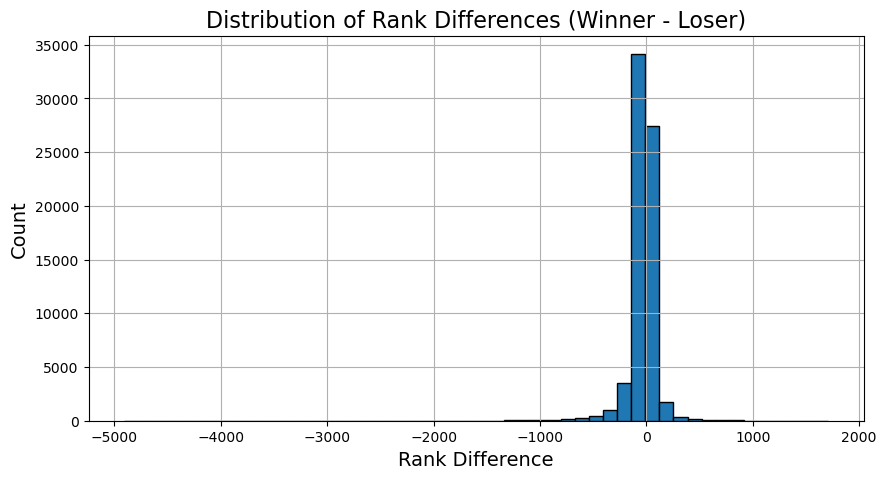

In [47]:
# Ranking statistics
full_df["WRank"] = pd.to_numeric(full_df["WRank"], errors="coerce")
full_df["LRank"] = pd.to_numeric(full_df["LRank"], errors="coerce")
rank_diff = full_df["WRank"] - full_df["LRank"]
print(rank_diff.describe())

plt.figure(figsize=(10,5))
plt.hist(rank_diff, bins=50, edgecolor='black')
plt.title("Distribution of Rank Differences (Winner - Loser)", fontsize=16)
plt.xlabel("Rank Difference", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(True)
plt.show()

Surface
Hard      38092
Clay      22270
Grass      7734
Carpet     1694
Name: count, dtype: int64


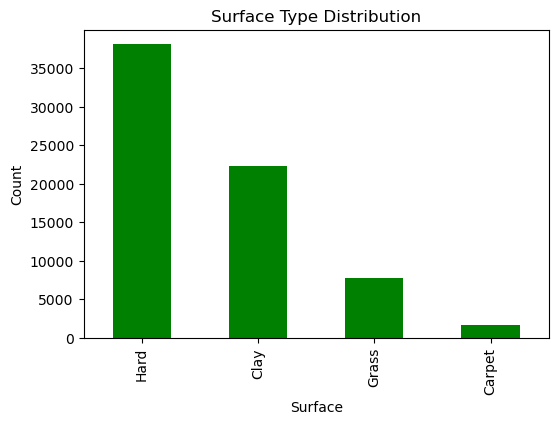

In [29]:
# Surface counts
surface_counts = full_df["Surface"].value_counts()
print(surface_counts)
plt.figure(figsize=(6,4))
surface_counts.plot(kind='bar', color='green')
plt.title("Surface Type Distribution")
plt.xlabel("Surface")
plt.ylabel("Count")
plt.show()

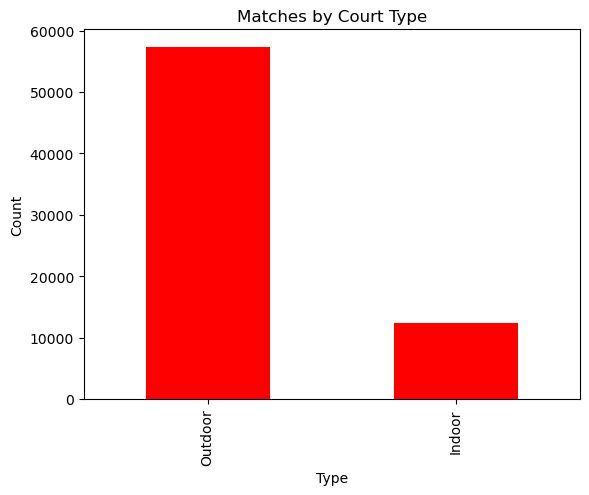

In [36]:
# Court type
indoor_counts = full_df["Court"].value_counts()
indoor_counts.plot(kind='bar', color="red")
plt.title("Matches by Court Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [17]:
# Unique player and tournaments
unique_players = set(full_df["Winner"]).union(set(full_df["Loser"]))
print("Unique players:", len(unique_players))
print("Unique tournaments:", full_df["Tournament"].nunique())

Unique players: 1819
Unique tournaments: 268


Best of
3.0    56488
5.0    13287
Name: count, dtype: int64


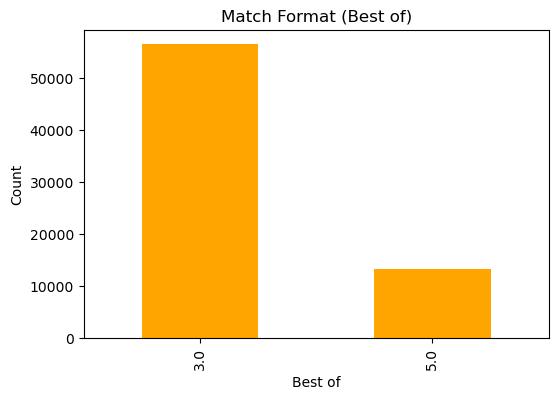

In [43]:
# Best of counts
best_of_counts = full_df["Best of"].value_counts()
print(best_of_counts)
plt.figure(figsize=(6,4))
best_of_counts.plot(kind='bar', color='orange')
plt.title("Match Format (Best of)")
plt.xlabel("Best of")
plt.ylabel("Count")
plt.show()


Year
2000    2963
2001    3056
2002    2806
2003    2816
2004    2877
2005    2910
2006    2908
2007    2824
2008    2689
2009    2731
2010    2679
2011    2675
2012    2621
2013    2657
2014    2560
2015    2630
2016    2626
2017    2635
2018    2652
2019    2593
2020    1267
2021    2489
2022    2632
2023    2705
2024    2729
2025    2616
2026     444
Name: count, dtype: int64


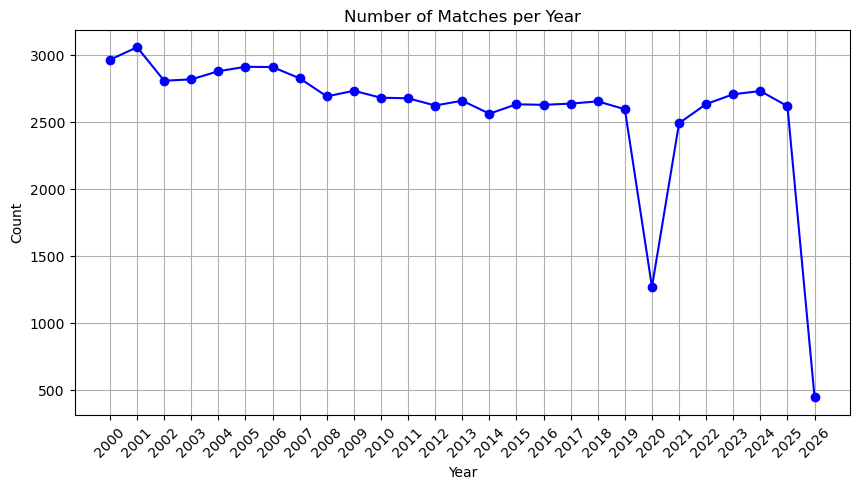

In [32]:
# Year counts
year_counts = full_df["Year"].value_counts().sort_index()
print(year_counts)
plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, marker='o', linestyle='-', color='blue')
plt.title("Number of Matches per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.xticks(year_counts.index, rotation=45)
plt.show()

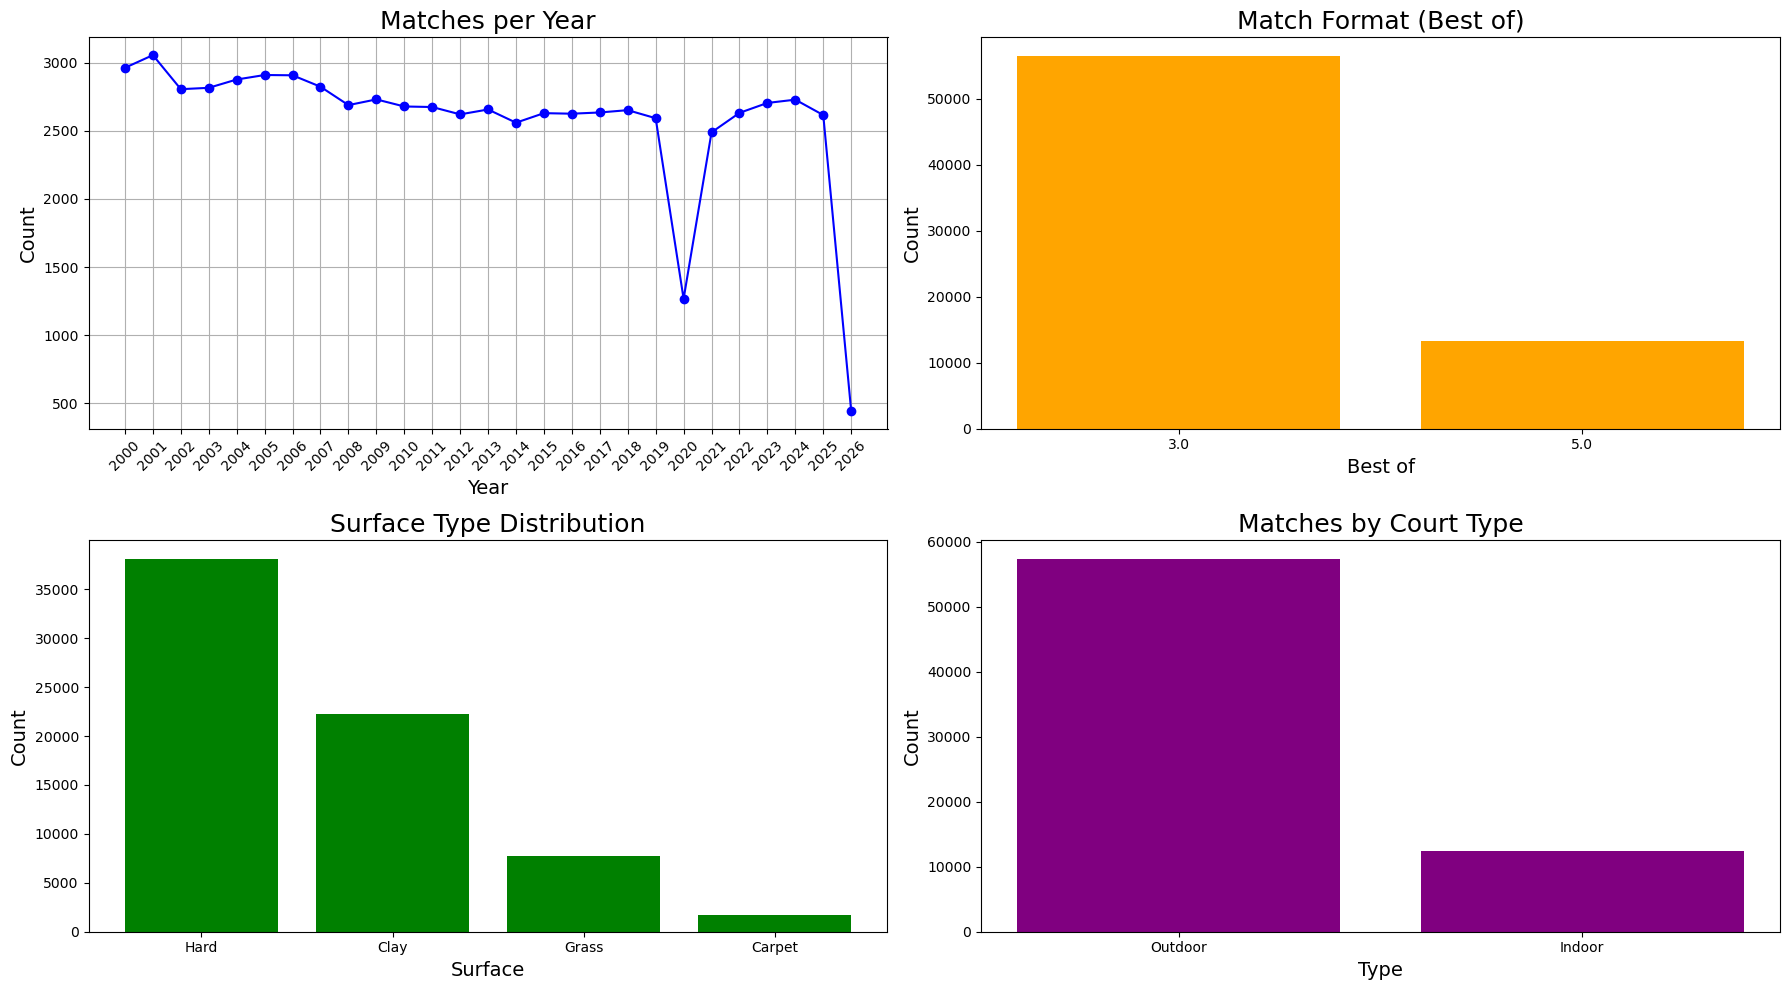

In [42]:
# Prepare counts
year_counts = full_df["Year"].value_counts().sort_index()
best_of_counts = full_df["Best of"].value_counts()
surface_counts = full_df["Surface"].value_counts()
indoor_counts = full_df["Court"].value_counts()  

# Create a figure with 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18,10))

# Line chart for Year
axes[0, 0].plot(year_counts.index, year_counts.values, marker='o', linestyle='-', color='blue')
axes[0, 0].set_title("Matches per Year", fontsize=18)
axes[0, 0].set_xlabel("Year", fontsize=14)
axes[0, 0].set_ylabel("Count", fontsize=14)
axes[0, 0].grid(True)
axes[0, 0].set_xticks(year_counts.index)
axes[0, 0].tick_params(axis='x', rotation=45)

# Bar chart for Best of
axes[0, 1].bar(best_of_counts.index.astype(str), best_of_counts.values, color='orange')
axes[0, 1].set_title("Match Format (Best of)", fontsize=18)
axes[0, 1].set_xlabel("Best of", fontsize=14)
axes[0, 1].set_ylabel("Count", fontsize=14)

# Bar chart for Surface
axes[1, 0].bar(surface_counts.index, surface_counts.values, color='green')
axes[1, 0].set_title("Surface Type Distribution", fontsize=18)
axes[1, 0].set_xlabel("Surface", fontsize=14)
axes[1, 0].set_ylabel("Count", fontsize=14)

# Bar chart for Indoor/Outdoor
axes[1, 1].bar(indoor_counts.index, indoor_counts.values, color='purple')
axes[1, 1].set_title("Matches by Court Type", fontsize=18)
axes[1, 1].set_xlabel("Type", fontsize=14)
axes[1, 1].set_ylabel("Count", fontsize=14)

plt.tight_layout()
plt.savefig("tennis_plot_collage.png", dpi=300)
plt.show()